In [1]:
import pandas as pd

# Apresentando o dataset
df = pd.read_csv('car_price_dataset.csv')
display(df)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


In [2]:
# Verificando o tipo de dado de cada atributo
df.dtypes

Brand            object
Model            object
Year              int64
Engine_Size     float64
Fuel_Type        object
Transmission     object
Mileage           int64
Doors             int64
Owner_Count       int64
Price             int64
dtype: object

In [3]:
# Apresentando se contém dados nulos e a quantidade por coluna
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [4]:
# Verificando se os nulos são linhas inteiras vazias ou dados dispersos
linhas_completamente_vazias = df.isnull().all(axis=1).sum()
linhas_com_algum_nulo = df.isnull().any(axis=1).sum()

print(f"Linhas com TODOS os valores nulos (completamente vazias): {linhas_completamente_vazias}")
print(f"Linhas com pelo menos UM valor nulo: {linhas_com_algum_nulo}")

if linhas_completamente_vazias == linhas_com_algum_nulo:
    print("\nCONCLUSÃO: Todos os nulos estão concentrados em linhas inteiras que estão totalmente em branco!")
else:
    print("\nCONCLUSÃO: Existem valores nulos dispersos pelo dataset (alguns dados preenchidos e outros faltando na mesma linha).")

Linhas com TODOS os valores nulos (completamente vazias): 0
Linhas com pelo menos UM valor nulo: 0

CONCLUSÃO: Todos os nulos estão concentrados em linhas inteiras que estão totalmente em branco!


In [5]:
# Removendo as linhas com valores nulos do dataset
df_limpo = df.dropna()

print(f"Número de linhas ANTES da limpeza: {df.shape[0]}")
print(f"Número de linhas DEPOIS da limpeza: {df_limpo.shape[0]}")
print(f"Total de linhas nulas apagadas: {df.shape[0] - df_limpo.shape[0]}\n")

# Verificação final para garantir que não sobrou nenhum nulo
print("Quantidade de nulos após a limpeza:")
print(df_limpo.isnull().sum())

Número de linhas ANTES da limpeza: 10000
Número de linhas DEPOIS da limpeza: 10000
Total de linhas nulas apagadas: 0

Quantidade de nulos após a limpeza:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


In [6]:
# Analisando se os dados numéricos estão normalizados
print("Análise das escalas numéricas ANTES da Normalização:")
colunas_numericas = df_limpo.select_dtypes(include=['int64', 'float64']).columns
colunas_para_normalizar = [col for col in colunas_numericas if col not in ['Price']]

display(df_limpo[colunas_para_normalizar].describe().loc[['min', 'max']])

print("\nCONCLUSÃO: Os dados numéricos NÃO estão normalizados.")

Análise das escalas numéricas ANTES da Normalização:


,Year,Engine_Size,Mileage,Doors,Owner_Count
min,2000.0,1.0,25.0,2.0,1.0
max,2023.0,5.0,299947.0,5.0,5.0



CONCLUSÃO: Os dados numéricos NÃO estão normalizados.


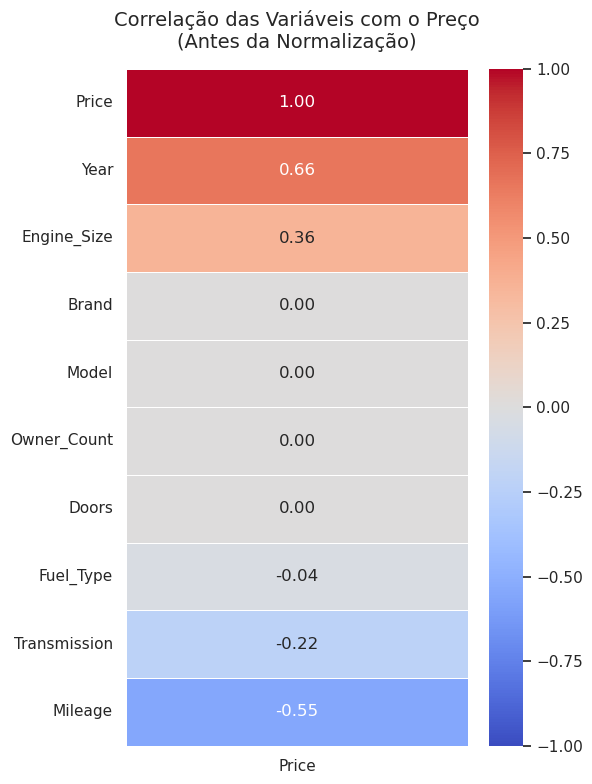

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapa de calor de correlação das variáveis APENAS com o Preço (Antes de Normalizar)
sns.set_theme(style="white")

df_corr = df_limpo.copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

correlacoes_preco = df_corr.corr()[['Price']].sort_values(by='Price', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(correlacoes_preco, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white')
plt.title('Correlação das Variáveis com o Preço\n(Antes da Normalização)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [8]:
# Normalizando as colunas numéricas MANUALMENTE (sem o uso do scikit-learn)
df_normalizado = df_limpo.copy()

for col in colunas_para_normalizar:
    valor_minimo = df_normalizado[col].min()
    valor_maximo = df_normalizado[col].max()
    df_normalizado[col] = (df_normalizado[col] - valor_minimo) / (valor_maximo - valor_minimo)

print("✅ Dados numéricos normalizados com sucesso (O Preço NÃO foi normalizado)!\n")
colunas_verificacao = colunas_para_normalizar + ['Price']
display(df_normalizado[colunas_verificacao].describe().loc[['min', 'max']])

✅ Dados numéricos normalizados com sucesso (O Preço NÃO foi normalizado)!



,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
min,0.0,0.0,0.0,0.0,0.0,2000.0
max,1.0,1.0,1.0,1.0,1.0,18301.0


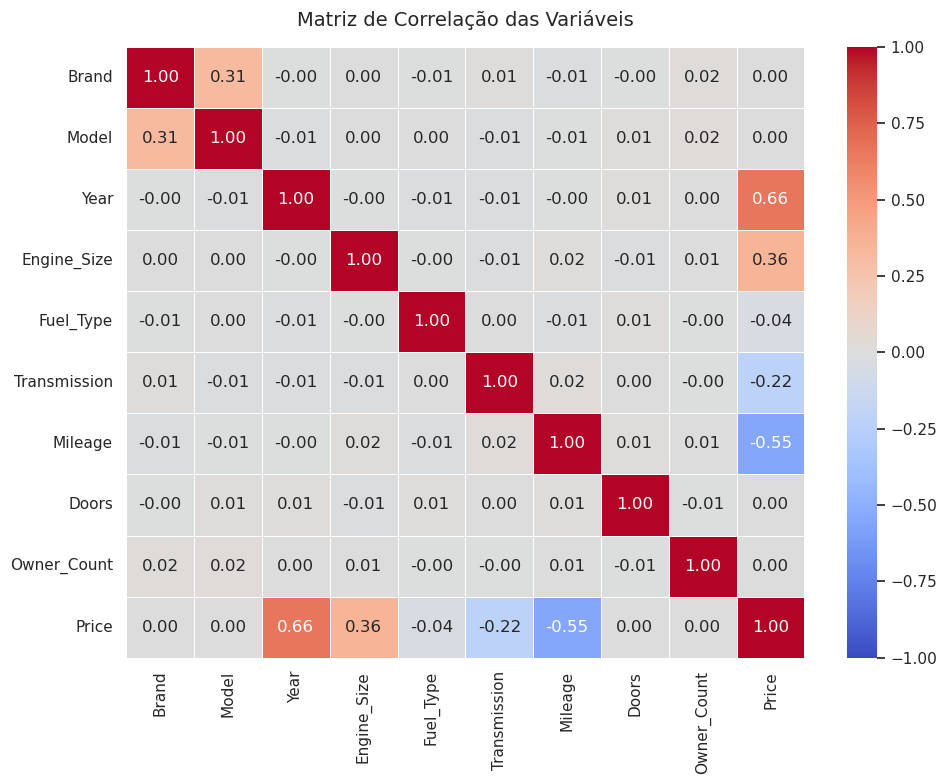

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# MATRIZ DE CORRELAÇÃO DE TODAS AS VARIÁVEIS (Gráfico Quadrado)
sns.set_theme(style="white")

df_matriz = df_limpo.copy()
for col in df_matriz.select_dtypes(include=['object']).columns:
    df_matriz[col] = df_matriz[col].astype('category').cat.codes

matriz_correlacao = df_matriz.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white')
plt.title('Matriz de Correlação das Variáveis', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

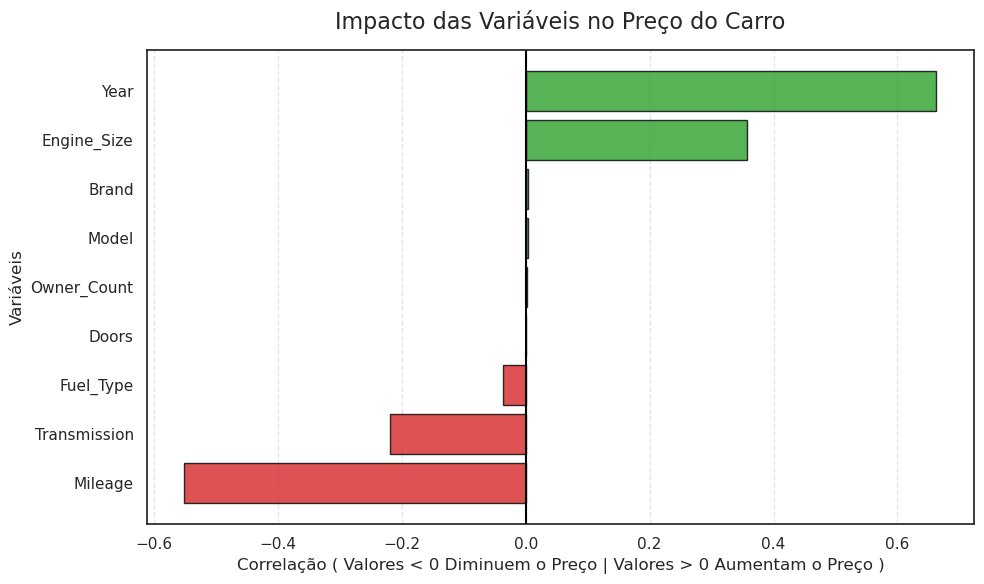

In [12]:
# Gráfico de barras horizontais mostrando o impacto (correlação) de cada variável no Preço
# Variáveis que diminuem o preço ficam à esquerda (vermelho)
# Variáveis que aumentam o preço ficam à direita (verde)

import matplotlib.pyplot as plt

if 'Price' in correlacoes_preco.index:
    corr_plot = correlacoes_preco.drop('Price')
else:
    corr_plot = correlacoes_preco.copy()

corr_plot = corr_plot.sort_values(by='Price')

plt.figure(figsize=(10, 6))
cores = ['#d62728' if x < 0 else '#2ca02c' for x in corr_plot['Price']]

plt.barh(corr_plot.index, corr_plot['Price'], color=cores, edgecolor='black', alpha=0.8)
plt.title('Impacto das Variáveis no Preço do Carro', fontsize=16, pad=15)
plt.xlabel('Correlação ( Valores < 0 Diminuem o Preço | Valores > 0 Aumentam o Preço )', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [13]:
# Removendo as 3 variáveis com correlação irrelevante (praticamente 0)
df_limpo = df_limpo.drop(columns=['Doors', 'Owner_Count', 'Model'])

# Atualizando a variável de correlações para o gráfico não dar erro
correlacoes_preco = correlacoes_preco.drop(index=['Doors', 'Owner_Count', 'Model'], errors='ignore')

print("Variáveis 'Doors', 'Owner_Count' e 'Model' foram removidas com sucesso!")


Variáveis 'Doors', 'Owner_Count' e 'Model' foram removidas com sucesso!


In [14]:
# Apresentando o dataset atualizado (agora sem as colunas Doors, Owner_Count e Model)
print("Formato do dataset após a remoção:", df_limpo.shape)
display(df_limpo.head())


Formato do dataset após a remoção: (10000, 7)


,Brand,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Price
0,Kia,2020,4.2,Diesel,Manual,289944,8501
1,Chevrolet,2012,2.0,Hybrid,Automatic,5356,12092
2,Mercedes,2020,4.2,Diesel,Automatic,231440,11171
3,Audi,2023,2.0,Electric,Manual,160971,11780
4,Volkswagen,2003,2.6,Hybrid,Semi-Automatic,286618,2867
